In [1]:
import sys
from pathlib import Path

THERMOIFT_SRC = Path("../thermoift/src").resolve()
if str(THERMOIFT_SRC) not in sys.path:
    sys.path.insert(0, str(THERMOIFT_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import AutoMinorLocator
from thermoift import PLOT_SETTINGS as ps

In [2]:
df = pd.read_csv("interfacial_results_dataset_A4.csv")

z_cols = [c for c in df.columns if c.startswith('z_')]

# ── Component count per source (z > 0.001) ──────────────────────────────
first_rows = df.drop_duplicates('source_id').set_index('source_id')
n_comp = first_rows[z_cols].apply(lambda r: (r > 0.001).sum(), axis=1)
print("Component count distribution:", n_comp.value_counts().sort_index().to_dict())
print("(no 8-component mixture in dataset; max is 7)\n")

# ── Manually selected sources: one per complexity tier ──────────────────
# Chosen to maximise P_bubble spread at 220 K
#   src 99 : 2-comp  CO2+H2                         P_bub(220K) = 68.5 MPa
#   src 21 : 4-comp  CO2+H2+CH4+H2S                 P_bub(220K) = 109.5 MPa
#   src 63 : 6-comp  CO2+H2+N2+Ar+CO+H2S            P_bub(220K) = 56.0 MPa
#   src 48 : 7-comp  CO2+H2+N2+CH4+O2+CO+H2S        P_bub(220K) = 33.3 MPa
top_ids = [99, 21, 63, 48]

# ── Composition labels (non-CO2 components) ─────────────────────────────
_comp_tex = {
    'hydrogen':         r'\mathrm{H_2}',
    'argon':            r'\mathrm{Ar}',
    'nitrogen':         r'\mathrm{N_2}',
    'methane':          r'\mathrm{CH_4}',
    'oxygen':           r'\mathrm{O_2}',
    'carbon monoxide':  r'\mathrm{CO}',
    'hydrogen sulfide': r'\mathrm{H_2S}',
}

def source_label(sid):
    row = first_rows.loc[sid]
    parts = [r'\mathrm{CO_2}']
    for comp, tex in _comp_tex.items():
        col = f'z_{comp}'
        if col in first_rows.columns and row[col] > 0.001:
            parts.append(tex)
    return r'$' + '+'.join(parts) + r'$'

COLORS = ps.color_10[:len(top_ids)]
labels = {sid: source_label(sid) for sid in top_ids}

print("Selected sources:")
pb220 = df[df['temperature'].between(219.9, 220.1)].drop_duplicates('source_id').set_index('source_id')['P_bubble']
for sid in top_ids:
    print(f"  src {sid:3d}  P_bub(220K)={pb220[sid]:.1f} MPa  {labels[sid]}")

Component count distribution: {2: 9, 3: 30, 4: 31, 5: 22, 6: 7, 7: 1}
(no 8-component mixture in dataset; max is 7)

Selected sources:
  src  99  P_bub(220K)=68.5 MPa  $\mathrm{CO_2}+\mathrm{H_2}$
  src  21  P_bub(220K)=109.5 MPa  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{CH_4}+\mathrm{H_2S}$
  src  63  P_bub(220K)=56.0 MPa  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{Ar}+\mathrm{N_2}+\mathrm{CO}+\mathrm{H_2S}$
  src  48  P_bub(220K)=33.3 MPa  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}+\mathrm{CO}+\mathrm{H_2S}$


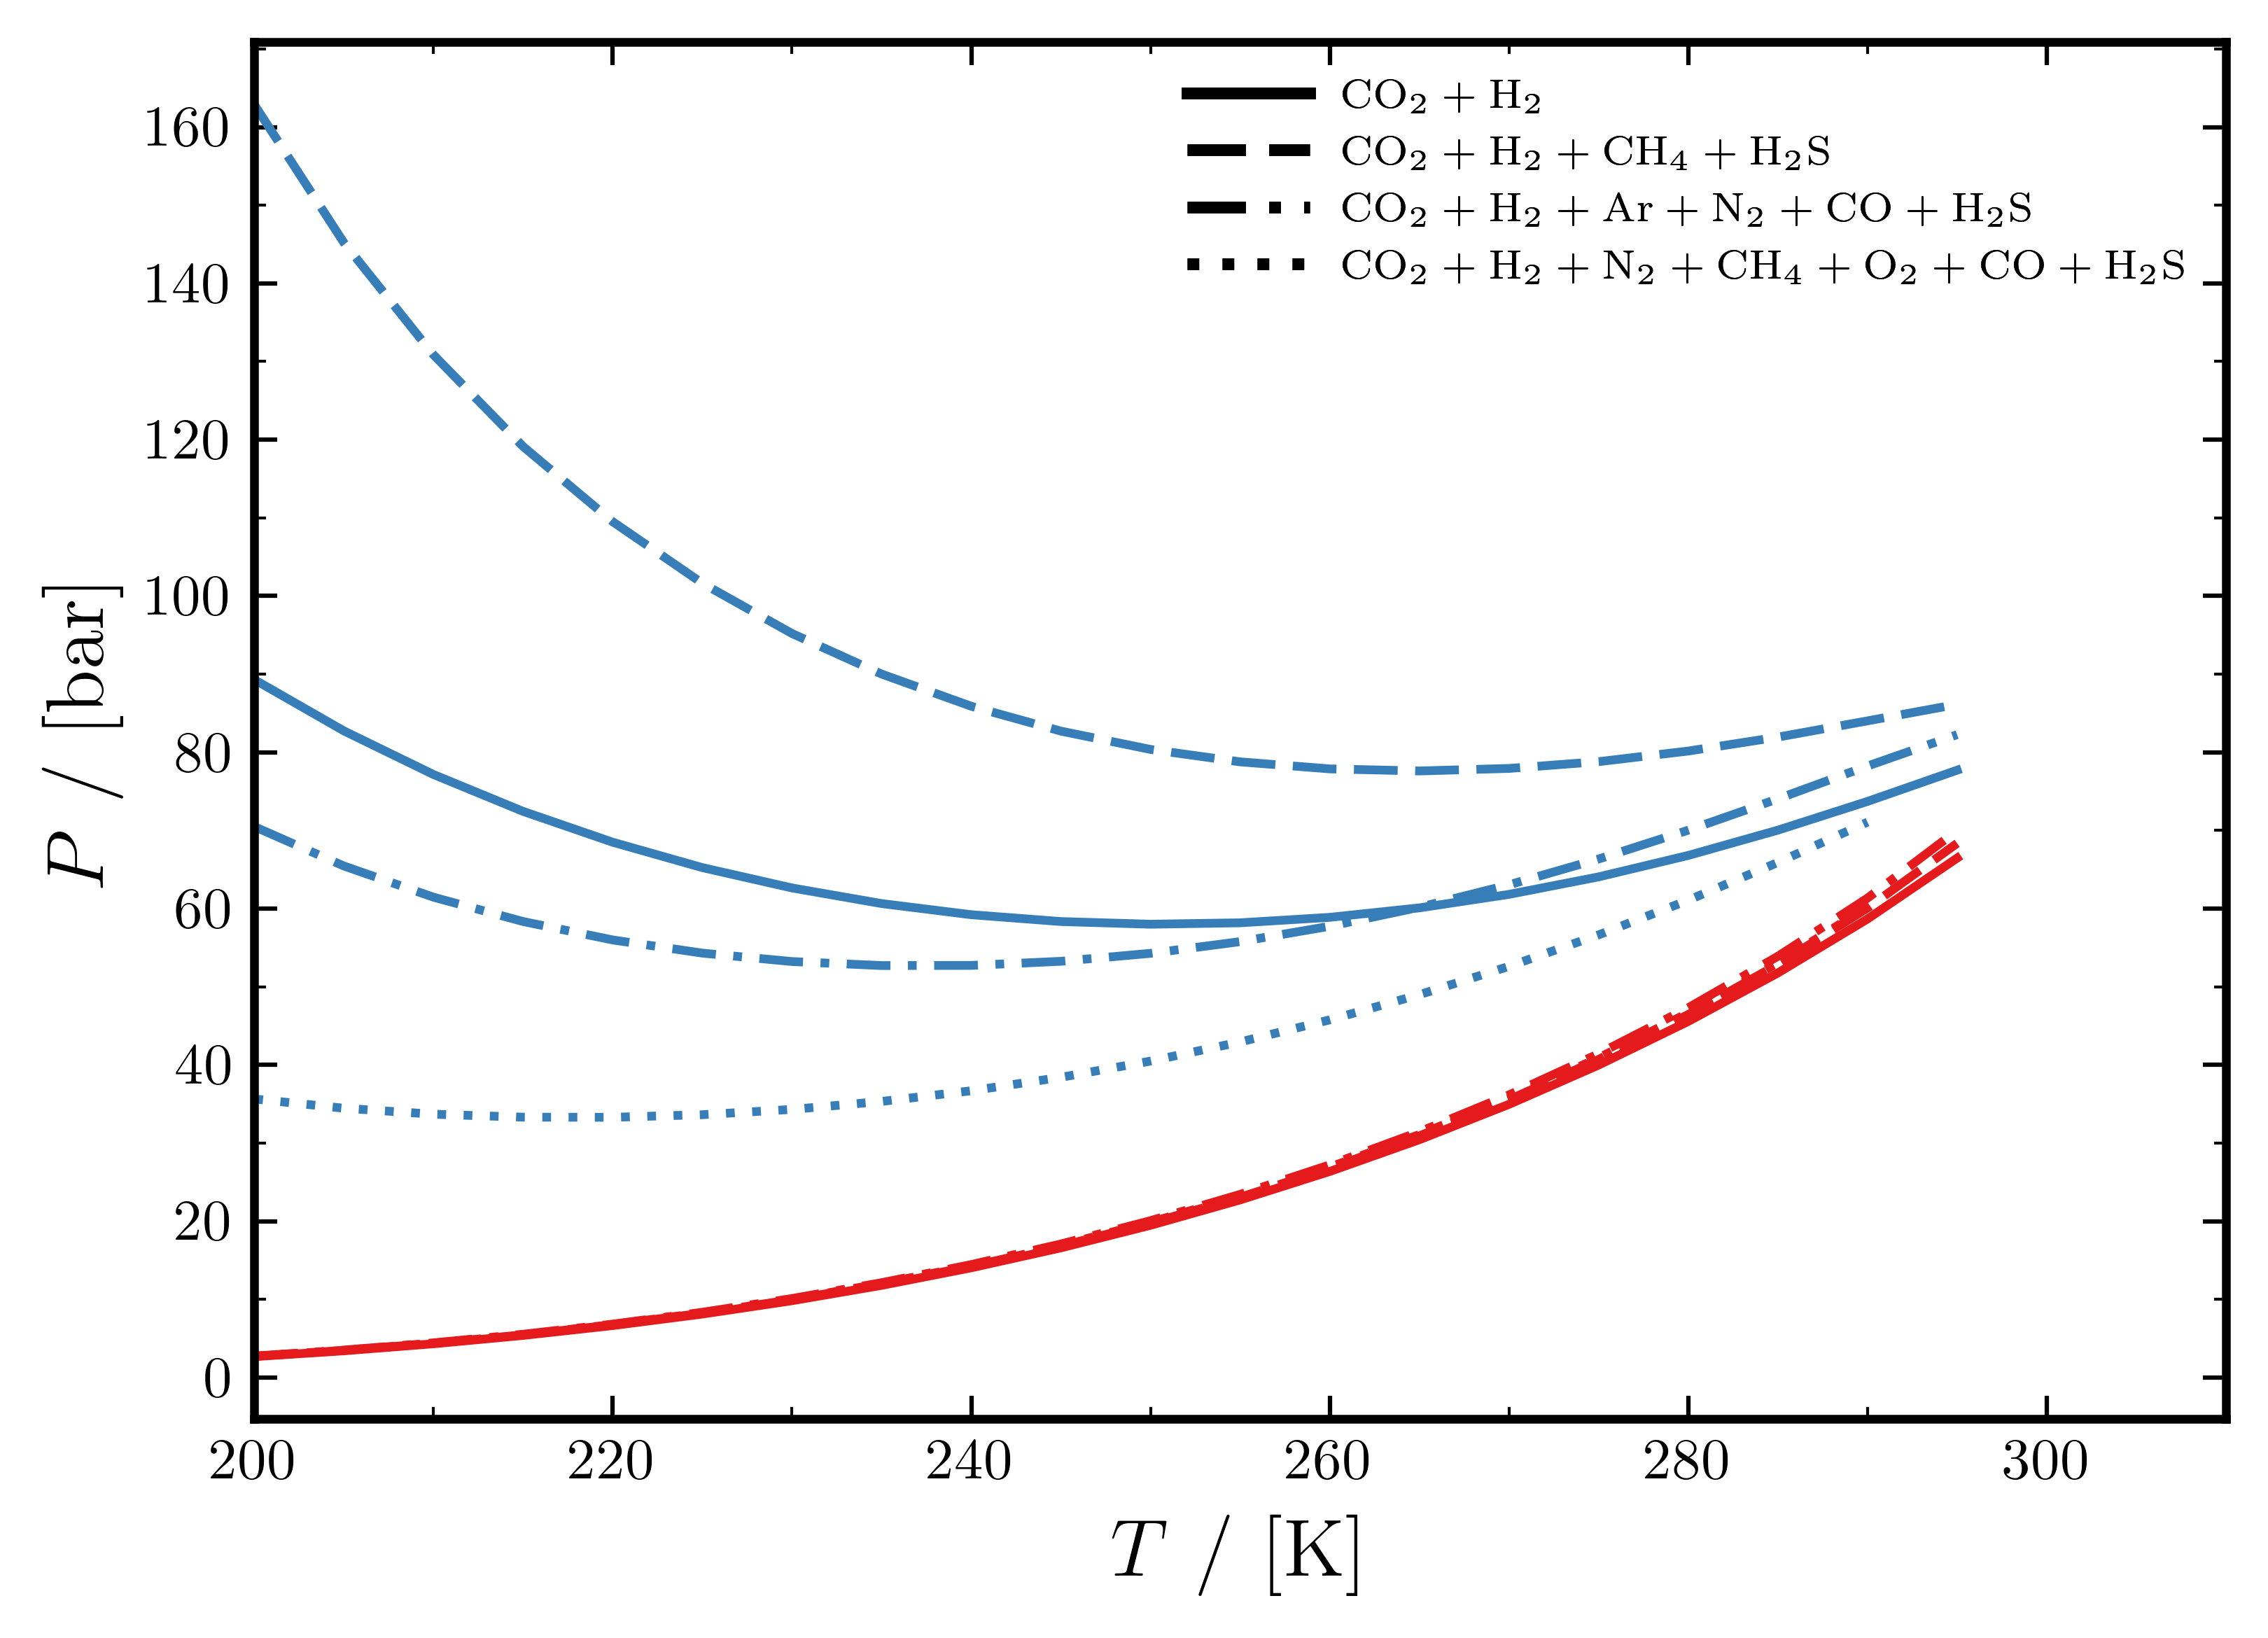

In [6]:
# ── Plot 1: PT Phase Map ────────────────────────────────────────────────
# Blue = bubble, Red = dew; line style differentiates source

LINE_STYLES = [
    '-',
    (0, (5, 2)),        # dashed — tighter than '--'
    (0, (5, 2, 1, 2)),  # dash-dot — tighter than '-.'
    (0, (1, 2)),        # dotted — tighter than ':'
]

envelope = (
    df[df['source_id'].isin(top_ids)]
    .drop_duplicates(subset=['source_id', 'temperature'])
    .sort_values(['source_id', 'temperature'])
)

fig, ax = ps.plot_init(w=5.5, h=4.0)

for sid, ls in zip(top_ids, LINE_STYLES):
    sub = envelope[envelope['source_id'] == sid].sort_values('temperature')
    ax.plot(sub['temperature'], sub['P_bubble'], color='#377eb8', lw=1.5, ls=ls)
    ax.plot(sub['temperature'], sub['P_dew'],    color='#e41a1c', lw=1.5, ls=ls)

# Source legend: black handles, one per line style
src_handles = [
    mlines.Line2D([], [], color='black', lw=2.0, ls=ls, label=labels[sid])
    for sid, ls in zip(top_ids, LINE_STYLES)
]
leg_src = ax.legend(handles=src_handles, fontsize=7, loc='upper right',
                    frameon=False, handlelength=3.0)
ax.add_artist(leg_src)

# Color legend: bubble / dew (lower right)
h_bub = mlines.Line2D([], [], color='#377eb8', lw=2.0, ls='-', label='bubble')
h_dew = mlines.Line2D([], [], color='#e41a1c', lw=2.0, ls='-', label='dew')
# ax.legend(handles=[h_bub, h_dew], fontsize=7, loc='lower right',
#           frameon=False, handlelength=3.0)

ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$',   fontsize=ps.label_fontsize)
ax.set_ylabel(r'$P$ $/$ $[\mathrm{bar}]$', fontsize=ps.label_fontsize)

ps.apply_axis_style(ax)
ax.tick_params(axis='both', which='major', bottom=True, top=True,
               left=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

plt.xlim(200, 310)
plt.tight_layout()
ps.save_plot(fig, 'sensitivity_PT_phase_map')
plt.show()

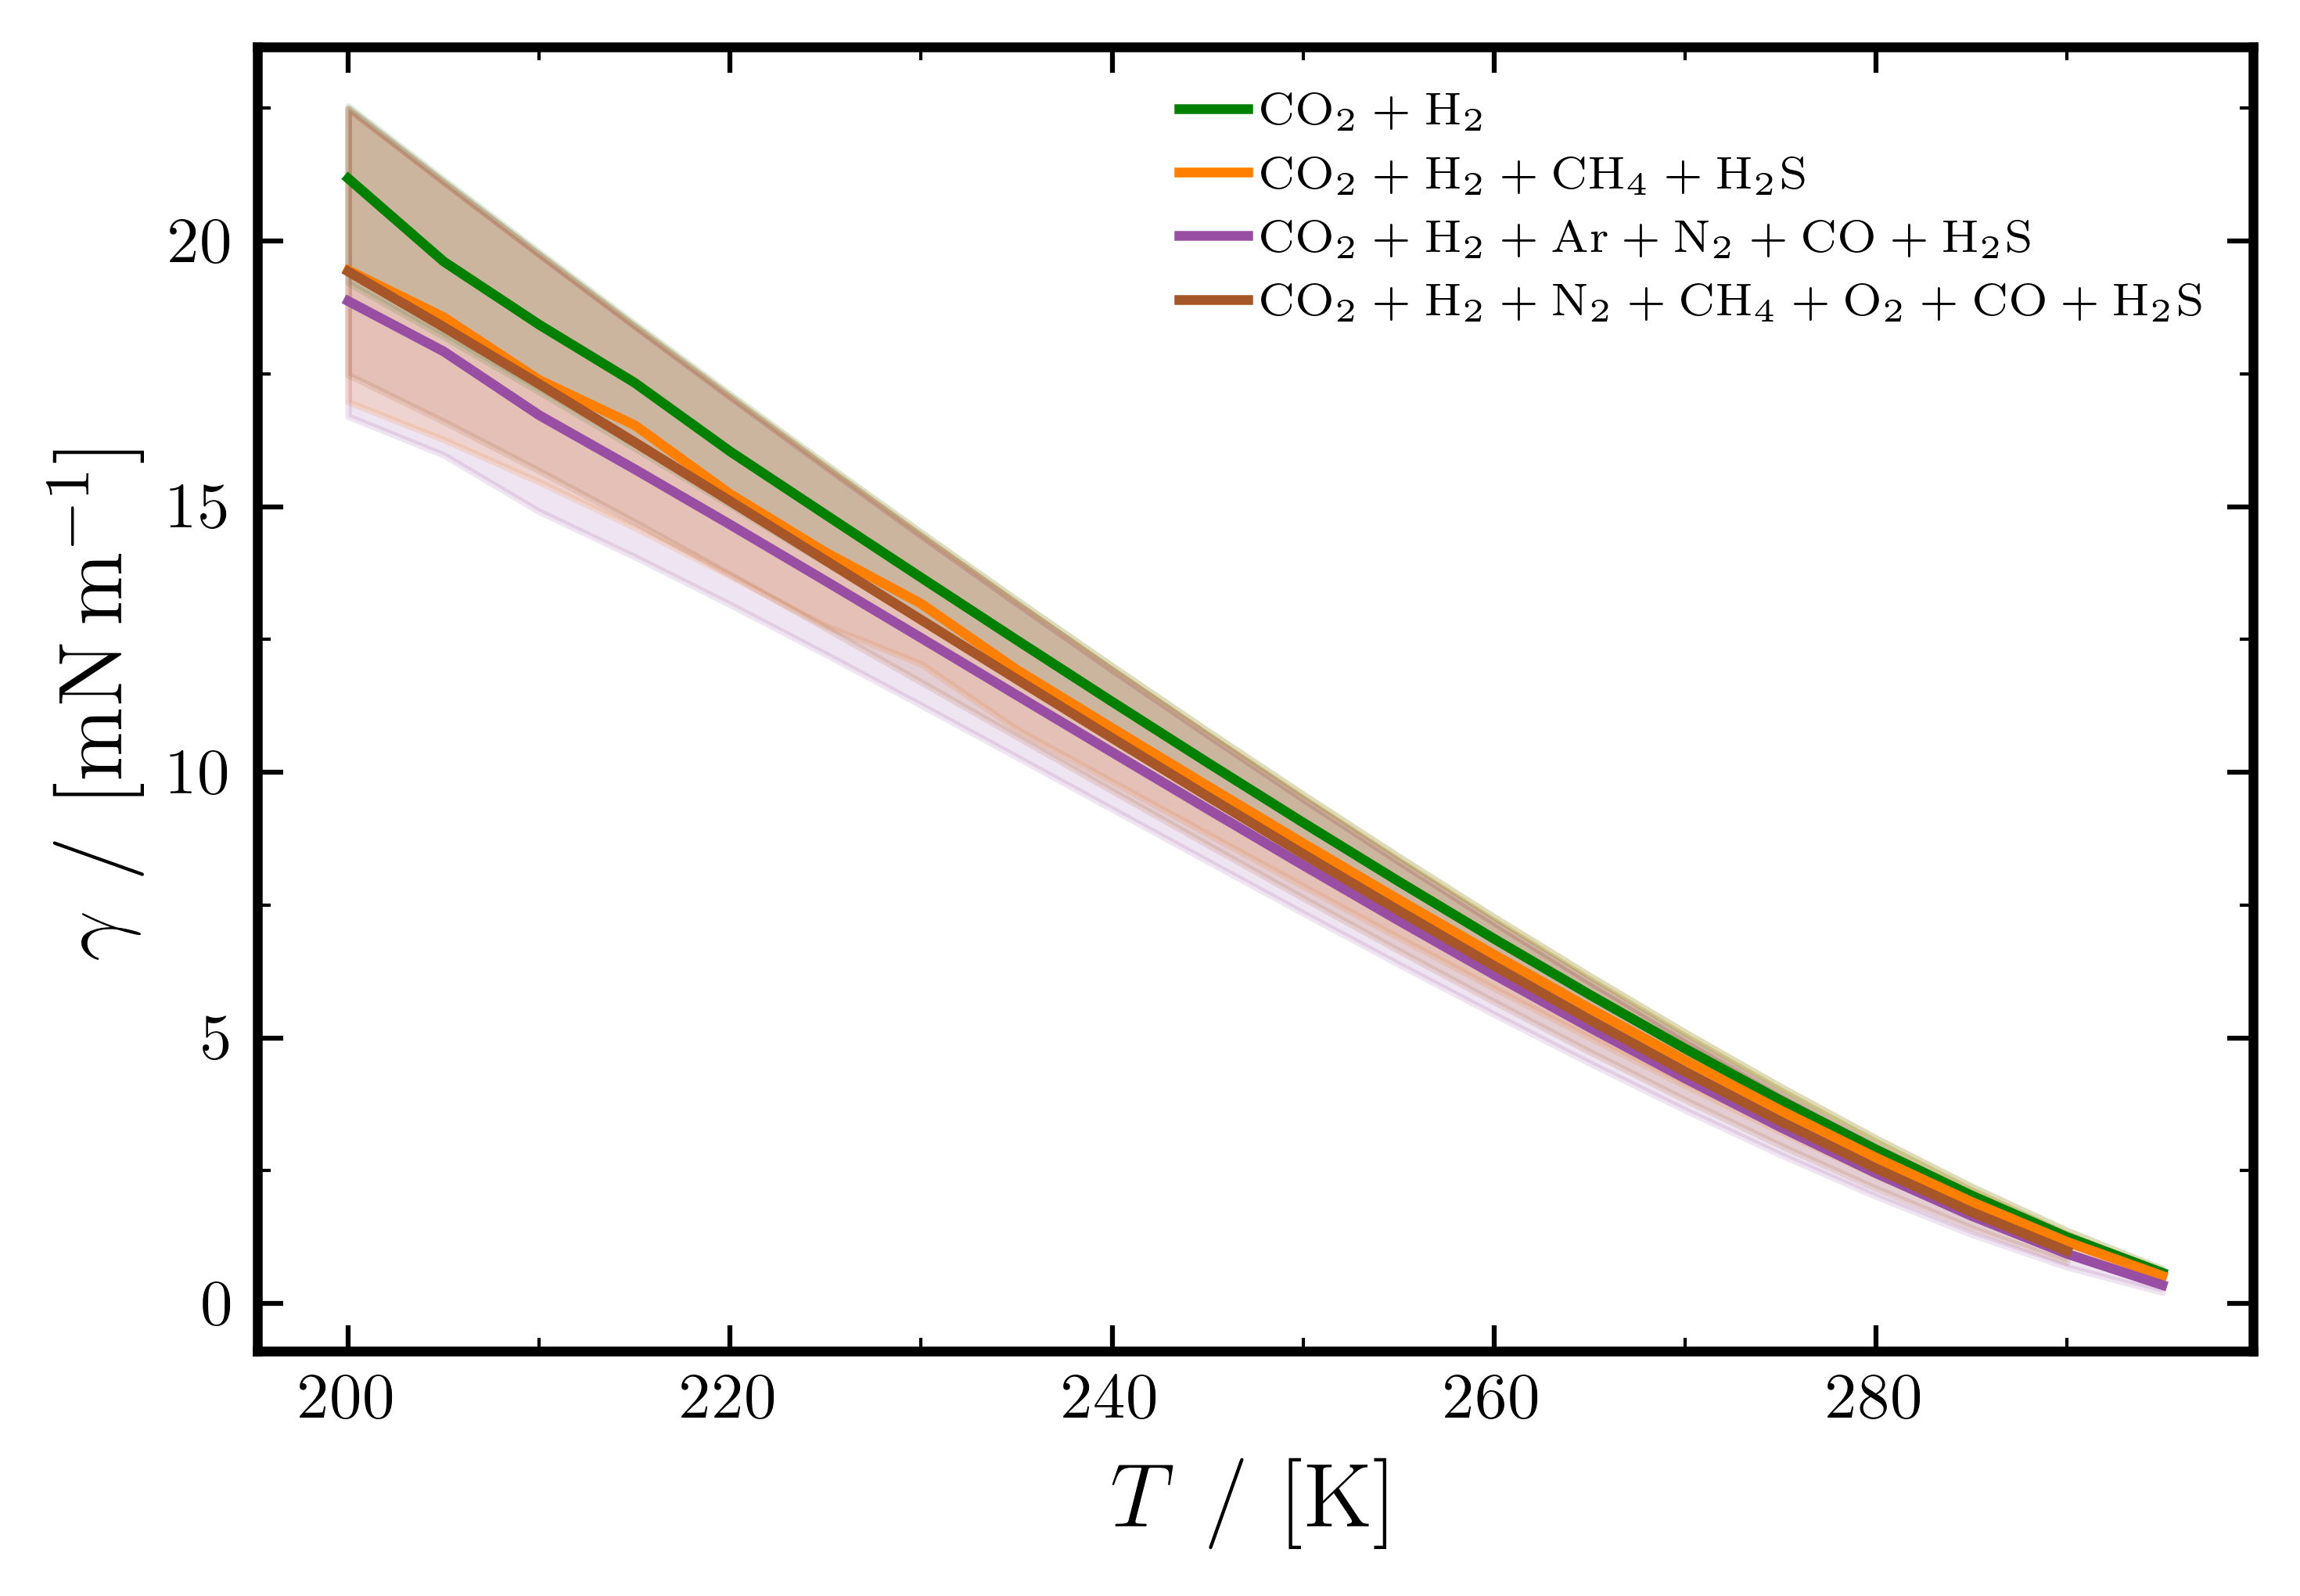

In [ ]:
fig, ax = ps.plot_init(w=5.0, h=3.5)

for sid, color in zip(top_ids, COLORS):
    sub  = df[df['source_id'] == sid]
    grp  = sub.groupby('temperature')['gamma']
    T_vals = sorted(sub['temperature'].unique())
    means  = [grp.get_group(T).mean() for T in T_vals]
    mins   = [grp.get_group(T).min()  for T in T_vals]
    maxs   = [grp.get_group(T).max()  for T in T_vals]

    ax.plot(T_vals, means, color=color, lw=1.5, ls='-', label=labels[sid])
    ax.fill_between(T_vals, mins, maxs, alpha=0.15, color=color)

ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$',                       fontsize=ps.label_fontsize)
ax.set_ylabel(r'$\gamma$ $/$ $[\mathrm{mN\,m^{-1}}]$',       fontsize=ps.label_fontsize)

ps.apply_axis_style(ax)
ax.tick_params(axis='both', which='major', bottom=True, top=True,
               left=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

leg = ps.style_legend(ax, fontsize=7, ncol=1, loc='upper right', frame=False)

plt.xlim(200, 310)
plt.tight_layout()
ps.save_plot(fig, 'sensitivity_gamma_vs_T')
plt.show()

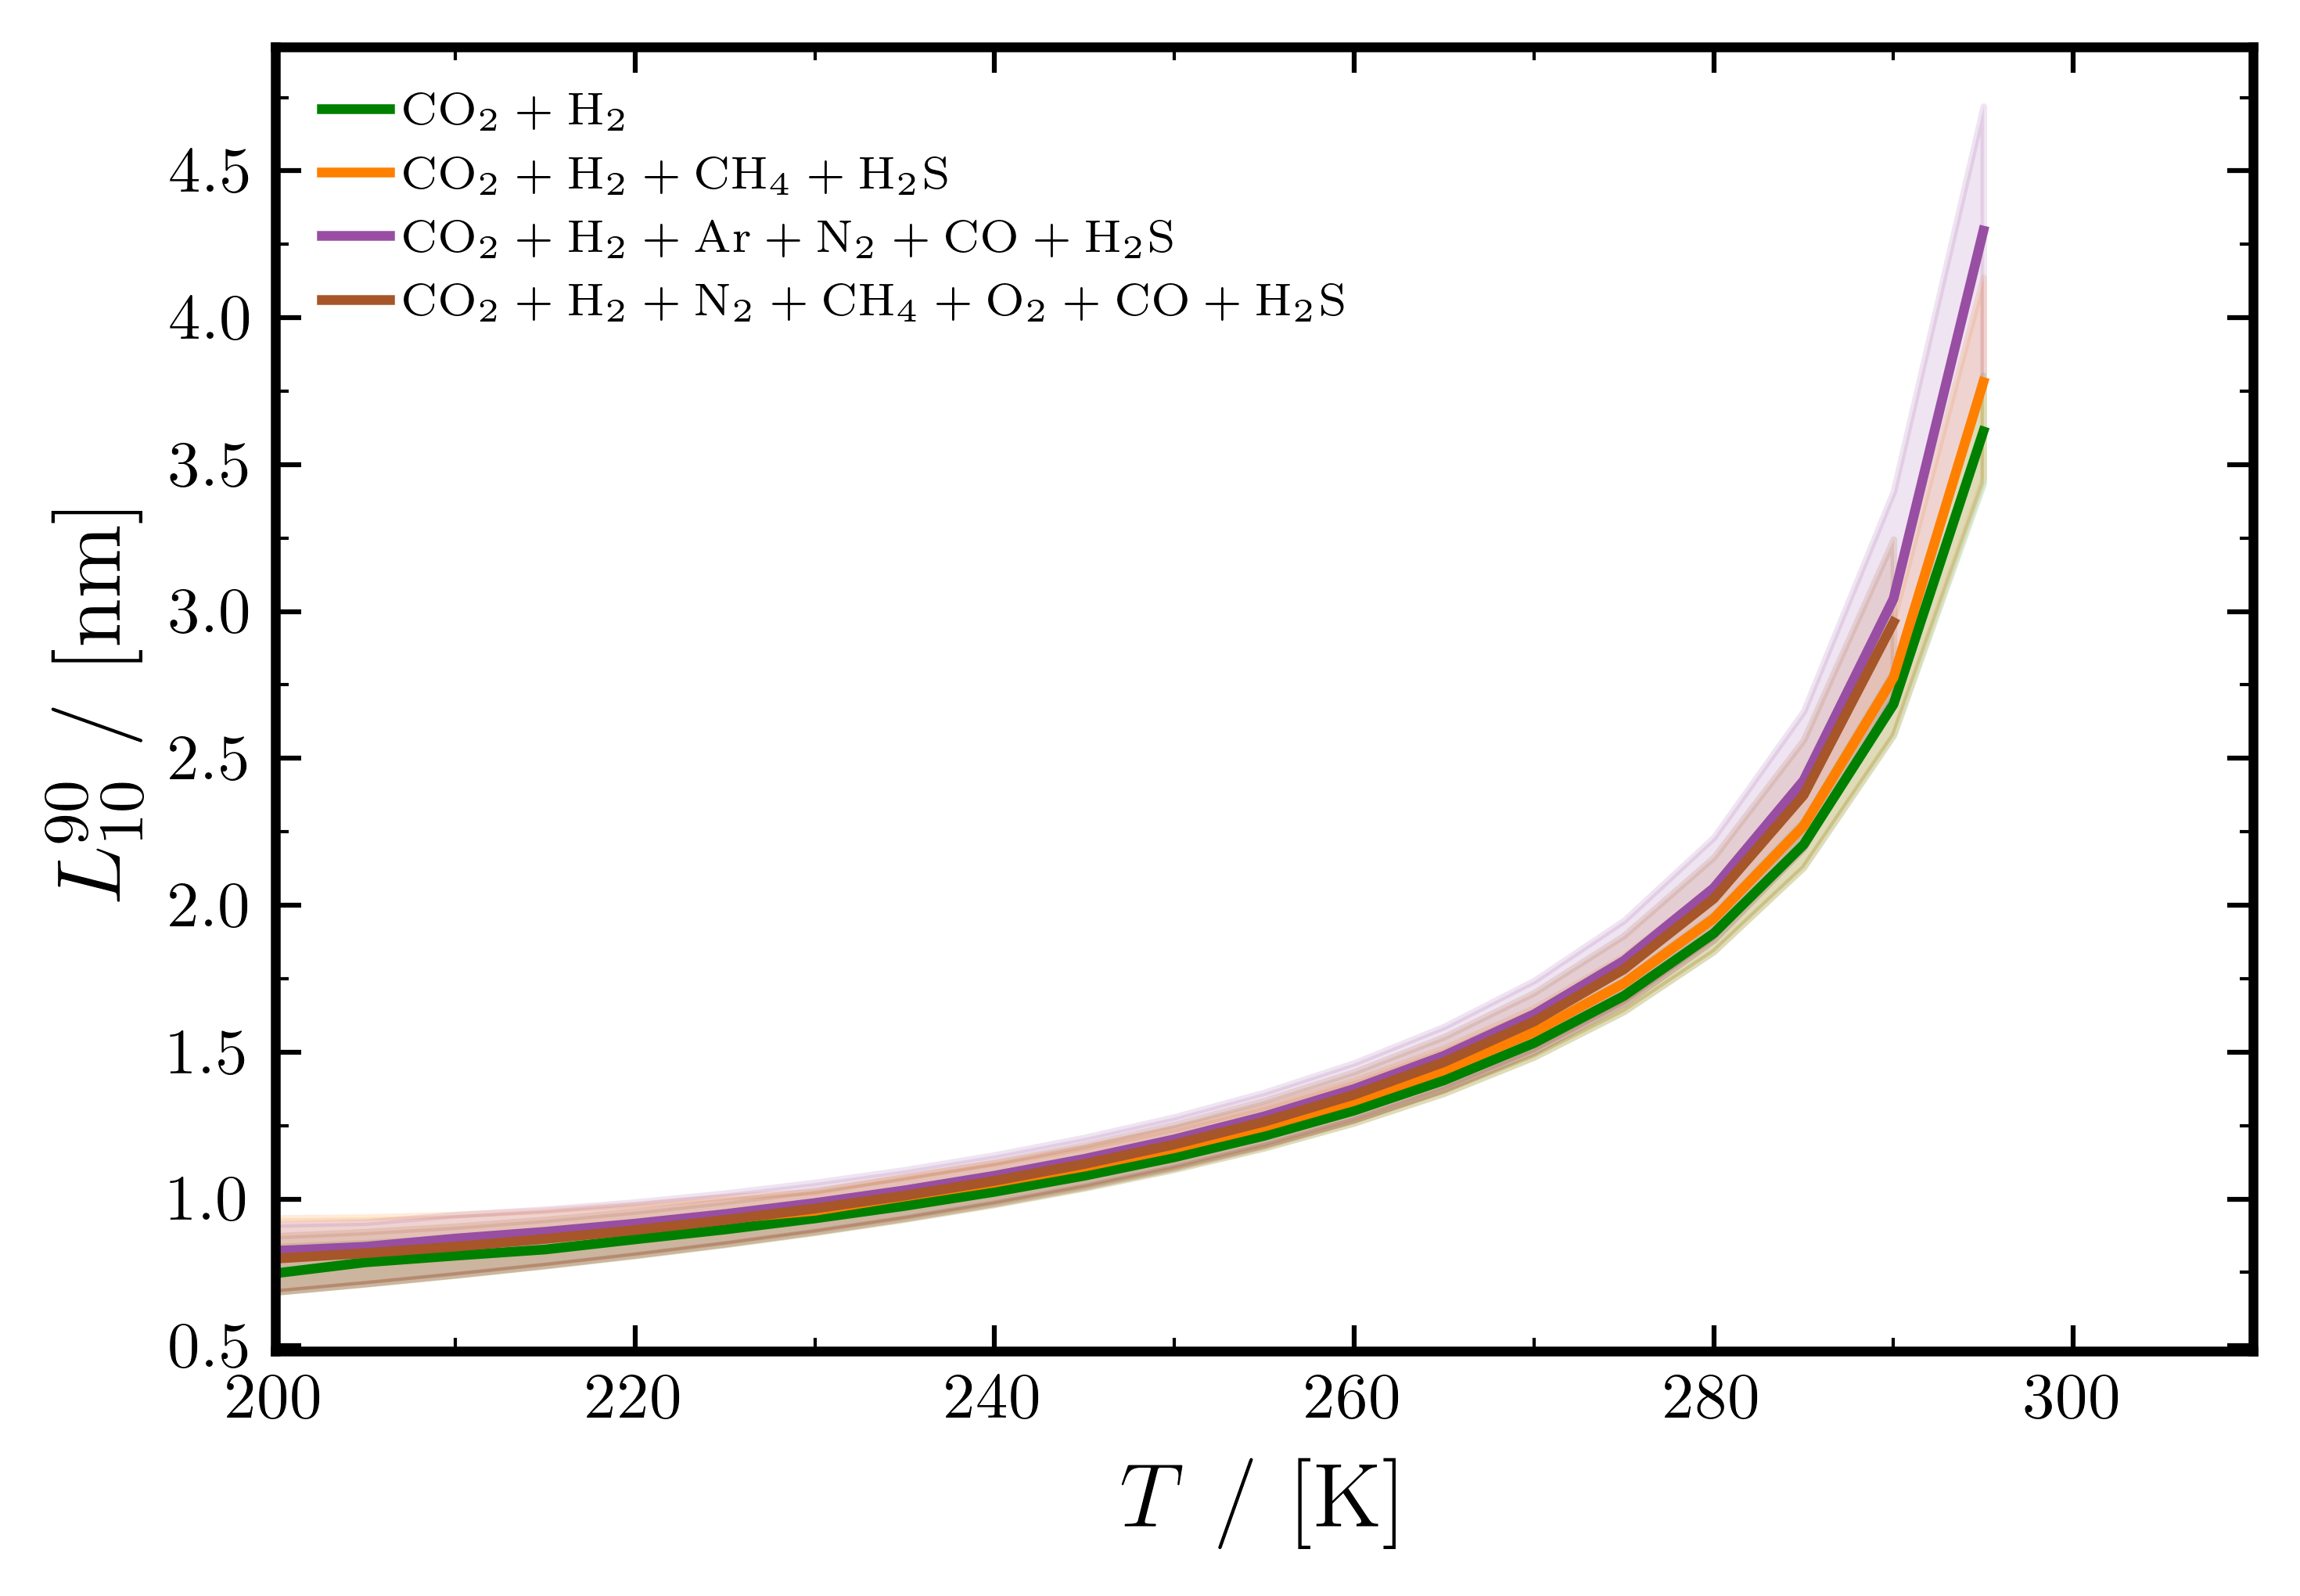

In [8]:
# ── Plot 3: Interfacial Thickness (L90_10) vs Temperature ──────────────

fig, ax = ps.plot_init(w=5.0, h=3.5)

for sid, color in zip(top_ids, COLORS):
    sub  = df[df['source_id'] == sid]
    grp  = sub.groupby('temperature')['interfacial_thickness']
    T_vals = sorted(sub['temperature'].unique())
    means  = [grp.get_group(T).mean() for T in T_vals]
    mins   = [grp.get_group(T).min()  for T in T_vals]
    maxs   = [grp.get_group(T).max()  for T in T_vals]

    ax.plot(T_vals, means, color=color, lw=1.5, ls='-', label=labels[sid])
    ax.fill_between(T_vals, mins, maxs, alpha=0.15, color=color)

ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$',                fontsize=ps.label_fontsize)
ax.set_ylabel(r'$L^{90}_{10}$ $/$ $[\mathrm{nm}]$',     fontsize=ps.label_fontsize)

ps.apply_axis_style(ax)
ax.tick_params(axis='both', which='major', bottom=True, top=True,
               left=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

leg = ps.style_legend(ax, fontsize=7, ncol=1, loc='upper left', frame=False)

plt.xlim(200, 310)
plt.tight_layout()
ps.save_plot(fig, 'sensitivity_thickness_vs_T')
plt.show()